### Multivariate Gaussian Clustering: Methods and Exploration ###

#### Emma Martin ####

Marine Seismology, University of Texas Institute for Geophysics 

Subsurface Machine Learning Course, The University of Texas at Austin
Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
Department of Geological Sciences, Jackson School of Geosciences
Workflow supervision and review by:

Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
Twitter | GitHub | Website | GoogleScholar | Geostatistics Book | YouTube | Applied Geostats in Python e-book | Applied Machine Learning in Python e-book | LinkedIn

Course TA: Elnara Rustamzade, Graduate Student, The University of Texas at Austin
LinkedIn

## Executive Summary: ##

Clustering of data can be performed in numerous ways, such as k-means clustering and DBSCAN, as we covered in this course. To generate a more robust understanding of clustering and explore additional methods not covered in class, Gaussian Mixture Modeling (GMM) can be used to work with data more flexibly, allowing for probabilities to be assigned to data points based on clustering rather than fixing data to one cluster. By iteratively improving the model under a series of assigned hyperparameters, clustering and underlying probabilities of the data set will be analyzed for a deeper understanding. Exploring this new method of clustering allows for deeper exploration into the possibilities for machine learning and its applications in a more relaxed space compared to other hard clustering methods.

### Background ###

Gaussian mixture modeling (GMM) is a probabilistic modeling method that assumes all data points within a set are generated from a finite number of Gaussian distributions with unknown parameters. After estimating gaussian distribution parameters, such as mean and variance, each data point is assigned a probability for which distribution it belongs to. This clustering method allows for clustering with overlapping data groups well pulling information about covariance data structures and the centers of latent Gaussians. 


In [1]:
### Import Packages

import geostatspy.GSLIB as GSLIB                              # GSLIB utilities, visualization and wrapper
import geostatspy.geostats as geostats                        # GSLIB methods convert to Python  
import geostatspy
print('GeostatsPy version: ' + str(geostatspy.__version__))

ignore_warnings = True                                        # ignore warnings?
import numpy as np                                            # ndarrays for gridded data
import pandas as pd                                           # DataFrames for tabular data
from scipy.stats import multivariate_normal                   # generate normal multivariate distributions
from scipy.stats import norm                                  # Perform statistical calculations related to normal distributions
import os                                                    # set working directory, run executables
import math                                                   # basic math operations
import random                                                 # for random numbers
import matplotlib.pyplot as plt                               # for plotting
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control of axes ticks
from matplotlib.colors import ListedColormap                  # custom color maps
from matplotlib.ticker import (MultipleLocator,AutoMinorLocator,NullLocator) # control of axes ticks
from matplotlib.patches import Ellipse                        # Plot elliptical formations
import matplotlib.cm as cm                                    # Color maps
import numpy.linalg as linalg                                 # for linear algebra
from statsmodels.stats.weightstats import DescrStatsW         # cDescriptive stats and tests with weights
plt.rc('axes', axisbelow=True)                                # plot all grids below the plot elements
if ignore_warnings == True:                                   
    import warnings
    warnings.filterwarnings('ignore')
cmap = plt.cm.inferno                                         # color map
seed = 77                                                     # random number seed 

import sys
#!{sys.executable} -m pip install shap
import shap
shap.initjs()

GeostatsPy version: 0.0.74


### Functions

The following functions will be used in the workflow:

In [2]:
# generate data points with unknown distributions
def generate_random_gmm_data(K=5, N=500, seed=None):
    if seed is not None:
        np.random.seed(seed)

    # Random cluster centers
    means = []
    for _ in range(K):
        means.append(np.random.uniform(-10, 10, size=2))
    means = np.array(means)

    # Random positive-definite covariance matrices
    covariances = []
    for _ in range(K):
        A = np.random.rand(2, 2)  # random 2x2 matrix
        cov = np.dot(A, A.T)  # makes symmetric positive-definite
        covariances.append(cov)

    # Random mixing weights (sum to 1)
    weights = np.random.dirichlet(alpha=np.ones(K))

    # Sample points for each cluster and combine
    X = []
    true_labels = []
    for k in range(K):
        Nk = int(weights[k] * N)
        samples = np.random.multivariate_normal(means[k], covariances[k], size=Nk)
        X.append(samples)
        true_labels.extend([k] * Nk)

    X = np.vstack(X)
    true_labels = np.array(true_labels)

    return X, true_labels, means, covariances, weights

# Initilization of parameters to start out the iterative clustering process
def initialize_parameters(X, K, seed=77):
    if seed is not None:
        np.random.seed(seed)

    N, D = X.shape  # number of samples, dimension

    # Randomly choose K points as initial means
    indices = np.random.choice(N, K, replace=False)
    means = X[indices]

    # Initialize covariances as identity
    covariances = np.array([np.eye(D) for _ in range(K)])

    # Initialize mixture weights uniformly
    weights = np.ones(K) / K

    return means, covariances, weights

# Multivariate Gaussian PDF
def gaussian_pdf(X, mean, cov):
    D = X.shape[1]
    cov_inv = np.linalg.inv(cov)
    diff = X - mean

    exponent = np.einsum('...i,ij,...j->...', diff, cov_inv, diff)
    norm_const = np.sqrt((2 * np.pi) ** D * np.linalg.det(cov))

    return np.exp(-0.5 * exponent) / norm_const

# E-step: Data assigned to posterior prob for each cluster
def E_step(X, means, covariances, weights):
    N, K = X.shape[0], len(weights)
    responsibilities = np.zeros((N, K))

    for k in range(K):
        responsibilities[:, k] = weights[k] * gaussian_pdf(X, means[k], covariances[k])

    # Normalize across clusters
    responsibilities /= responsibilities.sum(axis=1, keepdims=True)

    return responsibilities

# M-step: Means, cov matrices, and mixing coef are updated to maximize likelihood
def M_step(X, responsibilities):
    N, D = X.shape
    K = responsibilities.shape[1]

    Nk = responsibilities.sum(axis=0)  # Soft counts

    means = np.zeros((K, D))
    covariances = np.zeros((K, D, D))
    weights = np.zeros(K)

    for k in range(K):
        # Update mean
        means[k] = (responsibilities[:, k][:, np.newaxis] * X).sum(axis=0) / Nk[k]

        # Update covariance
        diff = X - means[k]
        covariances[k] = (responsibilities[:, k][:, np.newaxis] * diff).T @ diff / Nk[k]

        # Update mixture weight
        weights[k] = Nk[k] / N

    return means, covariances, weights

# Compute likelihood
def compute_log_likelihood(X, pi, mu, cov):
    N, K = X.shape[0], len(pi)
    
    log_likelihood = 0
    for i in range(N):
        # Weighted sum of Gaussian densities for point x_i
        prob = 0
        for k in range(K):
            prob += pi[k] * multivariate_normal.pdf(X[i], mean=mu[k], cov=cov[k])
        log_likelihood += np.log(prob)
    
    return log_likelihood

# Generate Gaussian Probability Figures
def plot_gmm_with_marginals(X, means, covariances, responsibilities):
    K = means.shape[0]
    labels = np.argmax(responsibilities, axis=1)
    colors = cm.viridis(np.linspace(0, 1, K))

    fig = plt.figure(figsize=(6, 4))
    grid = plt.GridSpec(4, 4, hspace=0.1, wspace=0.1)

    main_ax = fig.add_subplot(grid[1:, :3])
    y_hist = fig.add_subplot(grid[1:, 3], xticklabels=[], sharey=main_ax)
    x_hist = fig.add_subplot(grid[0, :3], yticklabels=[], sharex=main_ax)

    # === Main scatter and ellipses ===
    main_ax.scatter(X[:, 0], X[:, 1], c=labels, s=15, alpha=0.6, cmap='viridis')
    for k, color in enumerate(colors):
        mu = means[k]
        cov = covariances[k]
        eigvals, eigvecs = np.linalg.eigh(cov)
        order = eigvals.argsort()[::-1]
        eigvals, eigvecs = eigvals[order], eigvecs[:, order]
        angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
        width, height = 2 * np.sqrt(eigvals)
        ellipse = Ellipse(mu, width, height, angle, edgecolor=color, fill=False, linewidth=2)
        main_ax.add_patch(ellipse)
        main_ax.scatter(mu[0], mu[1], marker="x", s=200, linewidth=3, color=color)

    main_ax.set_xlabel("X₁")
    main_ax.set_ylabel("X₂")
    #main_ax.set_title("GMM Clustering with Marginal Gaussian Distributions")

    # === Top marginal: X₁ projections ===
    x_vals = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), 300)
    for k, color in enumerate(colors):
        mu_x = means[k][0]
        sigma_x = np.sqrt(covariances[k][0, 0])
        pdf_x = norm.pdf(x_vals, mu_x, sigma_x)
        pdf_x /= np.max(pdf_x)  # normalize for visual clarity
        x_hist.plot(x_vals, pdf_x, lw=2, color=color)
    x_hist.set_yticks([])
    x_hist.set_ylabel("Density")

    # === Right marginal: X₂ projections ===
    y_vals = np.linspace(np.min(X[:, 1]), np.max(X[:, 1]), 300)
    for k, color in enumerate(colors):
        mu_y = means[k][1]
        sigma_y = np.sqrt(covariances[k][1, 1])
        pdf_y = norm.pdf(y_vals, mu_y, sigma_y)
        pdf_y /= np.max(pdf_y)
        y_hist.plot(pdf_y, y_vals, lw=2, color=color)
    y_hist.set_xticks([])
    y_hist.set_xlabel("Density")

    plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=2.5, wspace=1.5, hspace=1.0)
    plt.savefig('/Users/emmamartin/Desktop/UT/machine_learning/FP_clustered_dist_RD.png',
            dpi=300, bbox_inches='tight')
    plt.show()

# Compute parameters based on cluster values 
def compute_num_params(K, D):
    cov_params = D * (D + 1) / 2
    mean_params = D
    weight_params = 1
    return K * (cov_params + mean_params + weight_params) - 1  # subtract 1 due to sum(weights)=1

# Compute Akaike Information Criterion to compare hyperparameter outputs (AIC = 2p − 2 log(L))
def compute_AIC(logL, K, D):
    p = compute_num_params(K, D)
    return 2 * p - 2 * logL

# Compute Bayesian Information Criterion to compare hyperparameter outputs (BIC = p log N − 2 log(L))
def compute_BIC(logL, K, D, N):
    p = compute_num_params(K, D)
    return p * np.log(N) - 2 * logL

# Run E and M steps together in single step to simplify code
def run_EM(X, K, max_iters=1000, tol=1e-4, seed=None):
    means, covariances, weights = initialize_parameters(X, K, seed=seed)
    log_likelihoods = []

    for it in range(max_iters):
        responsibilities = E_step(X, means, covariances, weights)
        means, covariances, weights = M_step(X, responsibilities)

        logL = compute_log_likelihood(X, weights, means, covariances)
        log_likelihoods.append(logL)

        if it > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break

    return log_likelihoods[-1], means, covariances, weights

### Load Data

The following workflow utilizes random data generation from unknown distributions. Data is randomly generated along arbitrary axis allowing for exploration into the clustering method and steps without having to utilize outside data sets or feature transformations. 

In [3]:
# Model parameters random generation
K = 10
N =1000
seed = 24

X, true_labels, means, cov, weights = generate_random_gmm_data(K=K, N=N, seed=seed)

column_names = ['X', 'Y']
df = pd.DataFrame(X, columns = column_names)
df.head()
df.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
X,996.0,1.310790,7.075177,-10.319897,-6.454851,1.420833,8.745057,13.718296
Y,996.0,-0.328396,4.853944,-8.488567,-3.979637,-2.002880,3.543534,9.699152


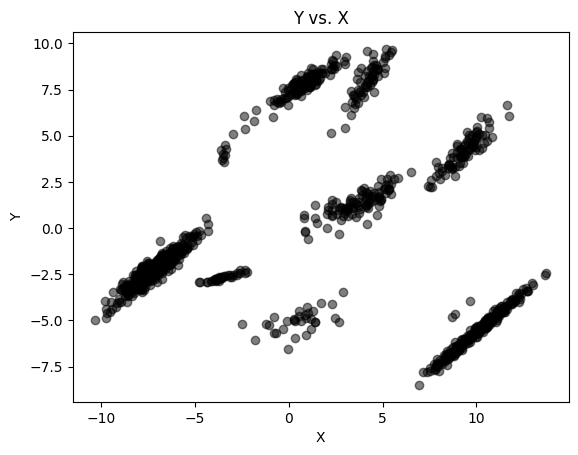

In [4]:
# plot the randomly generated data
plt.subplot()                                              
plt.scatter(df['X'], df['Y'],c='black',alpha=0.5,edgecolor='k',cmap = cmap)
plt.xlabel(column_names[0]); plt.ylabel(column_names[1]);
plt.title(column_names[1] + ' vs. ' + column_names[0])
plt.show()


By randomly generating data through the method outlined above, we can start to see expected clusters within the data to better inform our starting model parameters. For example, based on the seed and defined k value, there appear to be 8 clusters within the data that will have to be fit through the optomization of this clustering method. 

### Multivaraite Gaussian Clustering ###

Workflow Summary: 

- Utilizing random number generation, a random data set is generated for clustering that can be changed to show the robustness of my model
- Before clustering, values will be assigned randomly to the following parameters
    - Number of clusters
    - For each cluster
        - Means
        - Covariance matrices
        - Mixing coefficients
- To analyze fit and iteratively update the model, expectation-maximization (EM) will be performed
    - E-step: data points will be assigned posterior probabilities for each cluster under the current model parameters
    - M-step: means, covariance matrices, and mixing coefficients will be updated to maximize model likelihood based on previously assigned probabilities
    - Repeat until convergence
- Hyperparameter tuning:
    - Iterate over a range of potential values for both the number of components and the type of covariance matrix provided by scikit-learn
    - A GMM model will be fit to the data for each iteration of parameters
    - Analyzing fit with the Bayesian Information Criterion (BIC) and Akaine Information Criterion (AIC), a score will be assigned to each combination GMM model
    - Model with the lowest score (BIC and AIC) will be chosen as the best tuned hyperparameters
- Visualization of the optomized values will show the tuned model and associated best-fit Gaussian distributions. 
ameter values. 


### 1. Cluster and Perform E/M steps

Taking the randomly generated data, iteratively improve the model by performing EM steps to maiximize model likelihood


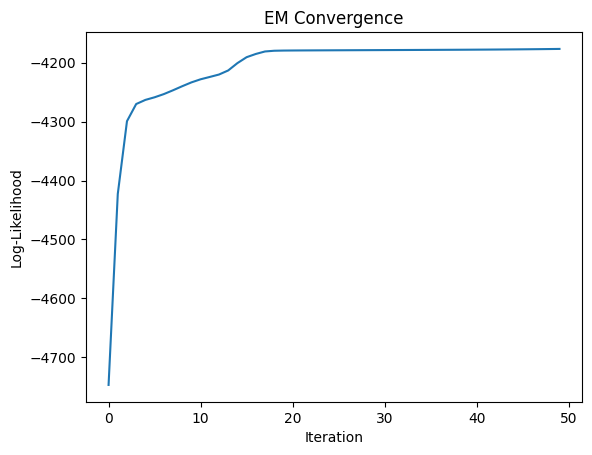

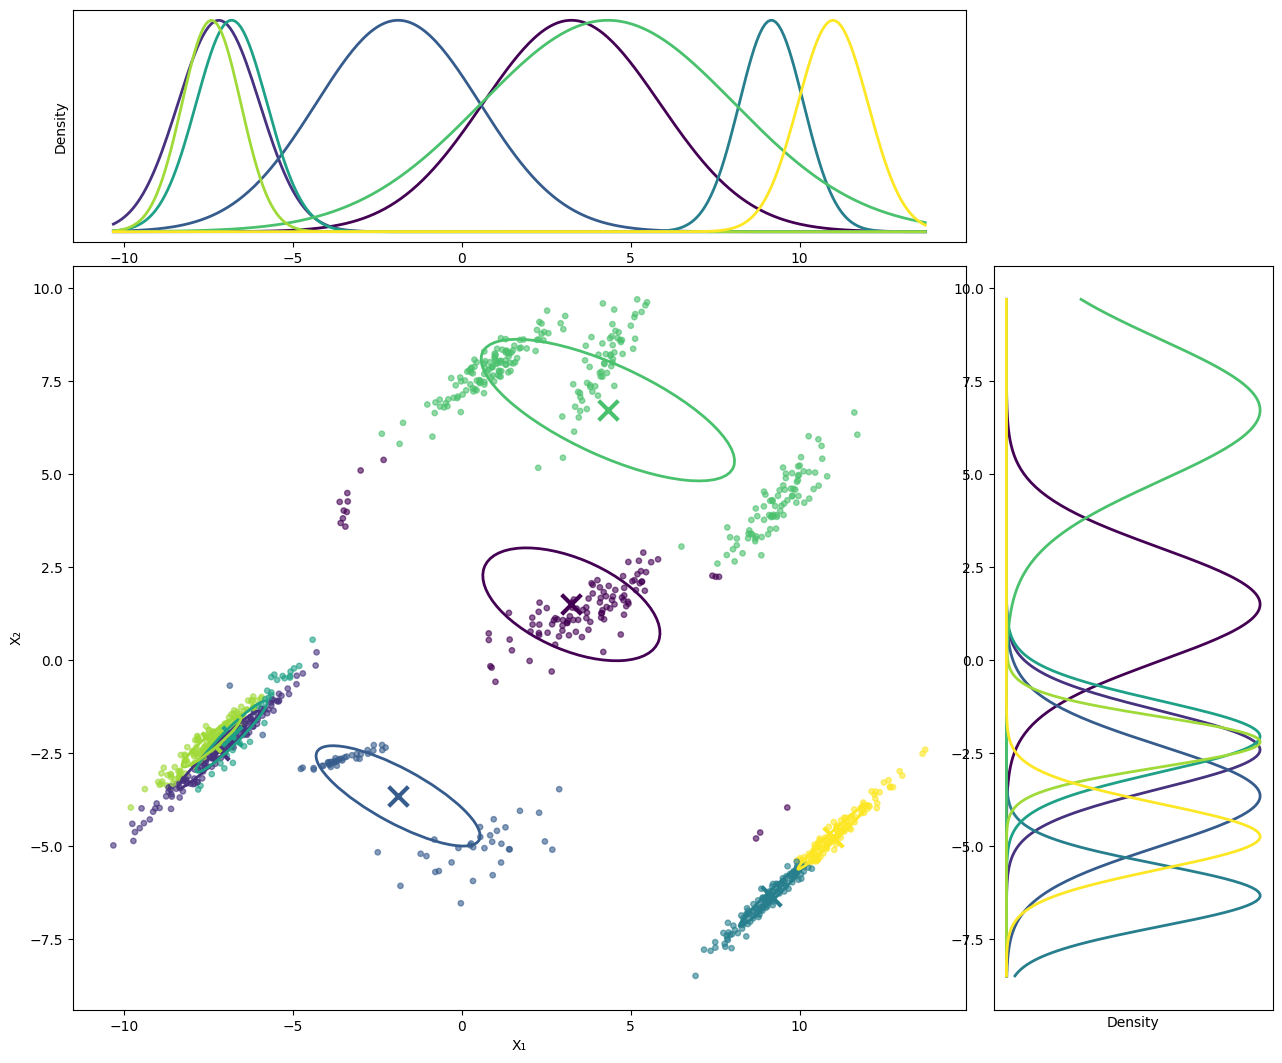

In [5]:
# Cluster
# Perform E/M steps and repeat until convergence

means, covariances, weights = initialize_parameters(X, 8, seed=seed)
log_likelihoods = []

max_iters = 50
tol = 1e-4  # Convergence tolerance

for iter in range(max_iters):

    responsibilities = E_step(X, means, covariances, weights)
    means, covariances, weights = M_step(X, responsibilities)

    logL = compute_log_likelihood(X, weights, means, covariances)
    log_likelihoods.append(logL)

    if iter > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
        print(f"Converged at iteration {iter}")
        break

plt.plot(log_likelihoods)
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.title("EM Convergence")
plt.show()

plot_gmm_with_marginals(X, means, covariances, responsibilities)

Using the provided functions, we can start to visualize the grouping of our data. It is seen that there is a clear improviement in the grouping based on the convergence in the EM steps of our iterative process. But, with our current number of groups (k value), the data is getting grouped into too many possible groupings. The majority of data should be within the ellipses that visualize the general area of the means between the two related gaussian curves that make up each grouping. To further improve how our data is getting grouped we can perform hyper parameter tuning to try a varaible number of possible groupings to find the minimized error and the best fit for the data groups. 

### 2. Hyperparameter Tuning

To improve the model, iterate over a range of cluster values and evaluate the model fit by minimizing AIC and BIC scores.

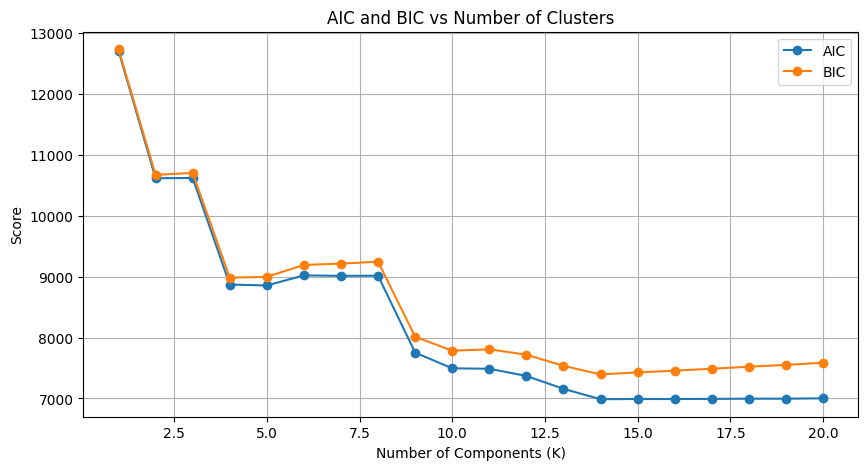

Best K (BIC): 14


In [6]:
Ks = range(1, 21)   # test K = 1 through 20
AICs = []
BICs = []
logLs = []

N, D = X.shape

for K in Ks:
    logL, means, covs, weights = run_EM(X, K, seed=77)
    logLs.append(logL)
    AICs.append(compute_AIC(logL, K, D))
    BICs.append(compute_BIC(logL, K, D, N))

plt.figure(figsize=(10,5))
plt.plot(Ks, AICs, marker='o', label="AIC")
plt.plot(Ks, BICs, marker='o', label="BIC")
plt.xlabel("Number of Components (K)")
plt.ylabel("Score")
plt.title("AIC and BIC vs Number of Clusters")
plt.legend()
plt.grid(True)
plt.show()

best_K = Ks[np.argmin(BICs)]
print("Best K (BIC):", best_K)


Hyperparameter tuning as represted by a plot with the scored AIC and BIC values against the possible numbers of components that could be used for the groupings. The minimized group value can be found by locating the lowest AIC and BIC score values. For the current randam data generation seed, the optimized number of groups is 14 groups. 

### Results

Using the optomized hyperparamaters found in the last step, reperform the EM steps and visualize the final modeled clustering of our data. 

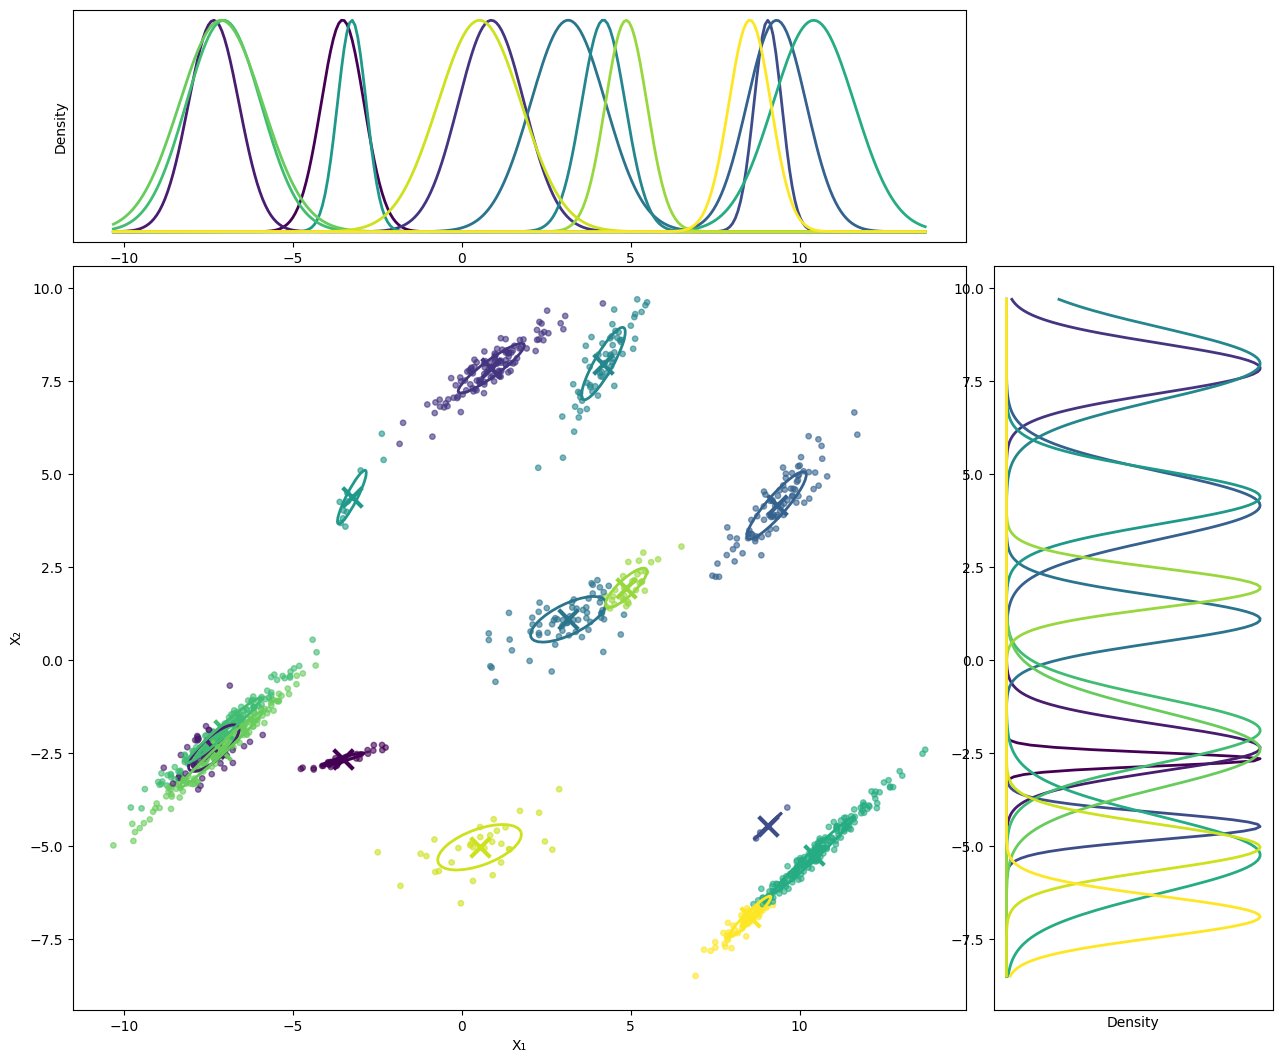

In [7]:
# --- After hyperparameter tuning ---
bestK = best_K  # whatever your loop produced

# Run EM with the selected K
final_logL, final_means, final_covariances, final_weights = run_EM(X, bestK)

# Compute responsibilities one last time
final_responsibilities = E_step(X, final_means, final_covariances, final_weights)

# Plot the final tuned model
plot_gmm_with_marginals(X, final_means, final_covariances, final_responsibilities)



Final grouping model, groups are shown by coloration of data points as well as subsequent gaussian distributions for each group (distributions are colored in the same manner the data points are). It can be seen, in comparasin to the grouping visualization shown before hyperparamter tuning, that by changing up the number of groups we are better able to fit the data resulting in more concise and informative data clusters. 

#### Conclusions ####

GMM clustering is a useful tool to visualize how data groups are related to different gaussian distrubitons well allowing for data overlap and non circular cluster shapes. Using this clustering method allows for a robust view of data relationships well maintaining a more nuanced approach to clustering assignments and data structure. Though incredibly useful, it can be seen in the examples above that this clustering method requires longer computational time compared to hard clustering methods that avoid data overlap and non-gaussian data. 

#### References ####
- 2.1. Gaussian mixture models. (n.d.). Scikit-Learn. Retrieved December 1, 2025, from https://scikit-learn/stable/modules/mixture.html
- Cluster Using Gaussian Mixture Model—MATLAB & Simulink. (n.d.). Retrieved December 1, 2025, from https://www.mathworks.com/help/stats/clustering-using-gaussian-mixture-models.html
- Gaussian Mixture Models Clustering—Explained. (n.d.). Retrieved December 1, 2025, from https://kaggle.com/code/vipulgandhi/gaussian-mixture-models-clustering-explained
- Michael Pyrcz. (2025). GeostatsGuy/MachineLearningDemos_Book: V0.2 (Version v0.2) [Computer software]. Zenodo. https://doi.org/10.5281/ZENODO.15169138 

- Coding assistance and checks for the initial setup were generated with the assistance of AI tools, based on guidance from ChatGPT (2025)

#### About Me ####

Emma Martin is a PhD student at the University of Texas Institute for Geophysics with a focus on seismic reflection processing and tectonic studies of the Puerto Rico Trench.er research interests include marine seismology, marine tectonics, active source seismic imaging, and tomographic inversion modeling. Passionate about advancing marine geophysics, she is eager to contribute to groundbreaking research in marine science and geophysical studies. Dedicated to expanding her expertise in seismic data analysis and geophysical methods to further her understanding of tectonic processes and seismically influenced geology. She is advised by Dr. Shuoshuo Han at the University of Texas Insitute for Geophysics. 

Previous work can be found on GitHub (emma-martin-sci) with a focus on data analytics and preperation related to marine seismic tomography. 

I can be reached at emmamartin@utexas.edu or www.linkedin.com/in/emma-martin-sci. 

My personal research and academic profile can be found at https://orcid.org/0009-0009-8837-2071


#### About the Supervising Professor ####

Michael Pyrcz is a professor in the Cockrell School of Engineering, and the Jackson School of Geosciences, at The University of Texas at Austin, where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also, the principal investigator of the Energy Analytics freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin an associate editor for Computers and Geosciences, and a board member for Mathematical Geosciences, the International Association for Mathematical Geosciences. 

Michael has written over 70 peer-reviewed publications, a Python package for spatial data analytics, co-authored a textbook on spatial data analytics, Geostatistical Reservoir Modeling and author of two recently released e-books, Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy and Applied Machine Learning in Python: a Hands-on Guide with Code.

All of Michael’s university lectures are available on his YouTube Channel with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his GitHub account, to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his Website.

Want to Work Together?
I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you!

Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

Michael

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: Twitter | GitHub | Website | GoogleScholar | Geostatistics Book | YouTube | Applied Geostats in Python e-book | Applied Machine Learning in Python e-book | LinkedInm